## Import Dependencies

In [1]:
# import subprocess
# subprocess.run(['pip', 'install', 'numpy'])
# subprocess.run(['pip', 'install', 'matplotlib'])
# subprocess.run(['pip', 'install', 'ubc-solar-phyics'])

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from physics.models.motor import BasicMotor

ModuleNotFoundError: No module named 'numpy'

In [ ]:
tire_radius_m = 0.2032 # from Simulation Brightside config

speeds_kmh = np.linspace(0, 100, 1000)
speeds_ms = speeds_kmh / 3.6
powers_w = np.linspace(0, 4000, 1000)
angular_speeds = speeds_ms / tire_radius_m
angular_speeds_mesh, powers_mesh = np.meshgrid(angular_speeds, powers_w)

# plt.imshow(speeds); plt.show()
# plt.imshow(powers); plt.show()

In [ ]:
with np.errstate(invalid='ignore'):
    mc_efficiencies = BasicMotor.calculate_motor_controller_efficiency(
        angular_speeds_mesh, powers_mesh, 1 # One second; convert J to W
    )

C:\Users\Jonah\Documents\UBCSolar\2025\data_analysis\venv\Lib\site-packages\physics\models\motor\basic_motor.py:167: RuntimeWarning: overflow encountered in square
  - (1.909e-4 * motor_torque_array ** 2) + (1.602e-6 * motor_angular_speed ** 3) \
C:\Users\Jonah\Documents\UBCSolar\2025\data_analysis\venv\Lib\site-packages\physics\models\motor\basic_motor.py:169: RuntimeWarning: overflow encountered in square
  - (2.306e-7 * motor_angular_speed * motor_torque_array ** 2) \
C:\Users\Jonah\Documents\UBCSolar\2025\data_analysis\venv\Lib\site-packages\physics\models\motor\basic_motor.py:169: RuntimeWarning: invalid value encountered in multiply
  - (2.306e-7 * motor_angular_speed * motor_torque_array ** 2) \
C:\Users\Jonah\Documents\UBCSolar\2025\data_analysis\venv\Lib\site-packages\physics\models\motor\basic_motor.py:170: RuntimeWarning: overflow encountered in power
  + (2.122e-06 * motor_torque_array ** 3) - (5.701e-09 * motor_angular_speed ** 4) \
C:\Users\Jonah\Documents\UBCSolar\2025\d

In [ ]:
with np.errstate(invalid='ignore'):
    motor_efficiencies = BasicMotor.calculate_motor_efficiency(
        angular_speeds_mesh, powers_mesh, 1 # One second; convert J to W
    )

# Compare to Mitsuba datasheet

Here I am using data points extracted from the Mitsuba datasheet (which I pulled from this [sheet](https://docs.google.com/spreadsheets/d/1LEIAGjOCqVJNqHJAKJ6j6IN2eyNm3XE_fCx6nnckNbM/edit?gid=0#gid=0)).

Recall that the 2d heatmap that's in our physics library is fit to the Daybreak motor, and nobody who helped fit this model is currently on the team so we can't have high confidence in its accuracy.

The reason we haven't updated it is because the only data we have for the new data is in the form of a single dynamometer plot which effectively gives us a line of data points across the heatmap to compare.

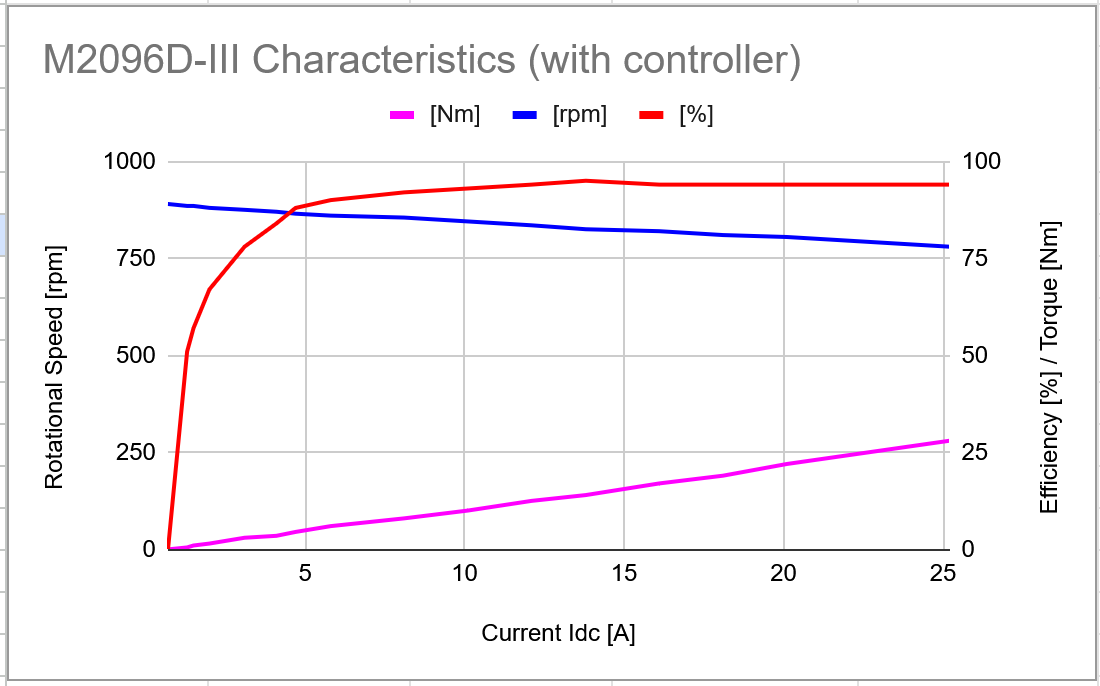

In [ ]:
powers = np.array([
    0,
    46,
    93,
    138,
    275,
    319,
    408,
    540,
    716,
    885,
    1093,
    1210,
    1460,
    1612,
    1855,
    2287,
])
rpms = np.array([
    890,
    885,
    885,
    880,
    875,
    870,
    865,
    860,
    855,
    845,
    835,
    825,
    820,
    810,
    805,
    780,
])
datasheet_efficiencies = np.array([
    0,
    51,
    57,
    67,
    78,
    84,
    88,
    90,
    92,
    93,
    94,
    95,
    94,
    94,
    94,
    94,
]) / 100

datasheet_speeds_kmh = (rpms / 60) * (2 * np.pi * tire_radius_m) * 3.6

plt.imshow(motor_efficiencies * mc_efficiencies, aspect='auto', origin='lower')

num_ticks = 6
x_tick_indices = np.linspace(0, len(speeds_kmh) - 1, num_ticks, dtype=int)
y_tick_indices = np.linspace(0, len(powers_w) - 1, num_ticks, dtype=int)

plt.xticks(x_tick_indices, np.round(speeds_kmh[x_tick_indices], 1))
plt.yticks(y_tick_indices, np.round(powers_w[y_tick_indices], 1))

plt.xlabel("Speed (km/h)")
plt.ylabel("Power (W)")
plt.title("Daybreak Motor + Motor Controller Efficiency, vs. Mitsuba data")
plt.colorbar(label="Efficiency (%)")

# Determine scaling based on pixel count and tick range.
pixels_per_kmh = 1000 / 100
pixels_per_watt = 1000 / 4000
plt.scatter(datasheet_speeds_kmh * pixels_per_kmh, powers * pixels_per_watt, c=datasheet_efficiencies)

plt.show()

NameError: name 'np' is not defined

In [ ]:
datasheet_speeds_kmh

array([68.17808979, 67.79506681, 67.79506681, 67.41204383, 67.02902086,
       66.64599788, 66.2629749 , 65.87995193, 65.49692895, 64.730883  ,
       63.96483705, 63.19879109, 62.81576812, 62.04972216, 61.66669919,
       59.75158431])